# SFT + LoRA

## LoRA

**预训练模型在微调过程中，权重更新矩阵 ΔW 具有显著的低秩特性。**
- 直觉上，预训练模型已经学会了丰富的通用表示，微调只需要在这个表示空间中做小幅度的“方向调整”。这种调整展开在一个低维子空间中

前向传播：
$$
W = W_0 + \Delta W
  = W_0 + \frac{\alpha}{r}BA
$$

- $W_0 \in \mathbb{R}^{d \times k}$：冻结的预训练权重，训练期间完全不变，保留模型的通用知识

- $A \in \mathbb{R}^{r \times k}$：下投影矩阵，将 $k$ 维输入压缩到 $r$ 维的低秩空间；使用高斯分布初始化，保证训练开始时有非零梯度

- $B \in \mathbb{R}^{d \times r}$：上投影矩阵，将 $r$ 维低秩表示映射回 $d$ 维输出空间；初始化为全零，确保训练开始时 $\Delta W = BA = 0$，即模型行为与基座模型完全相同，训练稳定性有保障

- $r \ll \min(d, k)$：秩，控制参数量（通常取 8, 16, 32, 64）。$r$ 越小，参数量越少，但表达能力越弱；$r$ 越大，表达能力越强，但参数量增加

- $\frac{\alpha}{r}$：缩放因子，控制 LoRA 更新的幅度。设置为 $\frac{\alpha}{r}$ 而非直接用 $\alpha$，是为了使实际缩放幅度与 $r$ 的选择解耦合：当 $\alpha = 2r$ 时，无论 $r$ 取何值，实际缩放因子始终为 2，方便跨不同 $r$ 值的实验对比


**C = BA 低秩分解的意义：** <br>
<br>
$A \in \mathbb{R}^{r \times k}$，$B \in \mathbb{R}^{d \times r}$<br>
故，$BA \in \mathbb{R}^{d \times k}$，即 $BA$ 的秩为 $r$（因为 $A$ 的秩为 $r$，$B$ 的秩为 $r$）<br>
由于 r ≪ min(d,k)，所以 $BA$ 的秩小于等于 $r$。所以无论如何改变 $A$ 或 $B$ 中的数值（即参数更新），$BA$ 的秩都不会超过 $r$。

**$\alpha$ 与 r 解耦的意义（参数化惯例）：** <br>
<br>
把 LoRA 看作一个团队：
- $r$：团队有多少人
- $BA$：所有人的意见之和
- $\frac{1}{r}$：对意见取平均
- $\alpha$：最终将团队意见放大多少倍

这实际上是一种超参数约定：
- $r$：控制低秩分支的容量；
- $\alpha$：相对于秩设置缩放强度；
- $\alpha / r$：实际乘在 $BA$ 上的缩放值。

## SFT 结束条件

1. 训练/验证 loss 收敛
- 连续 2~3 个 epoch 训练/验证 loss 不再下降（或下降幅度 < 0.01）：结束 SFT
- 训练 loss 持续下降但验证 loss 开始上升：过拟合

2. 格式正确率 >= 90%
- RL 阶段的奖励函数会进一步强化正确格式

3. 任务准确率超过随机水平
- SFT 模型不需要很高的准确率，但需要有意义地超过基座模型的 zero-shot 表现（不经过当前任务的样例训练，直接完成任务的能力）

4. 仍然存在输出多样性
- GRPO 需要采样多个输出，确保模型的多样性

## 建议总结

SFT 只需要让模型学会 Agent 行为的基本格式，需要给 RL 阶段的探索留下足够的空间。

| 建议 | 详情 |
|:---|:---|
| Epoch 数 | 2–3 个 epoch 是安全区间，超过 3 个需要格外警惕过拟合 |
| Early Stopping | 以验证 Loss 为基准，patience=3 eval steps |
| 保存多个检查点 | 保存 epoch 1/2/3 的检查点，RL 阶段可以回退到多样性更好的版本 |
| 先做 RL 预实验 | 用 SFT 检查点做小规模 GRPO（100–200 步），观察 mean_reward 是否上升 |
| 不要追求 SFT SOTA | SFT 的最高准确率 ≠ RL 后的最高准确率 |

## LoRA 变体

### QLoRA：量化 LoRA

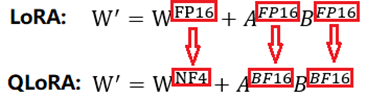

16 位浮点数：
- FP16:  [符号:1] [指数:5] [尾数:10]
- BF16:  [符号:1] [指数:8] [尾数:7] （牺牲精度换更大范围）

#### 三个关键技术

**NF4 量化：**

将原区间量化到 16 个不等距区间内（因为模型参数基本服从标准正态分布）
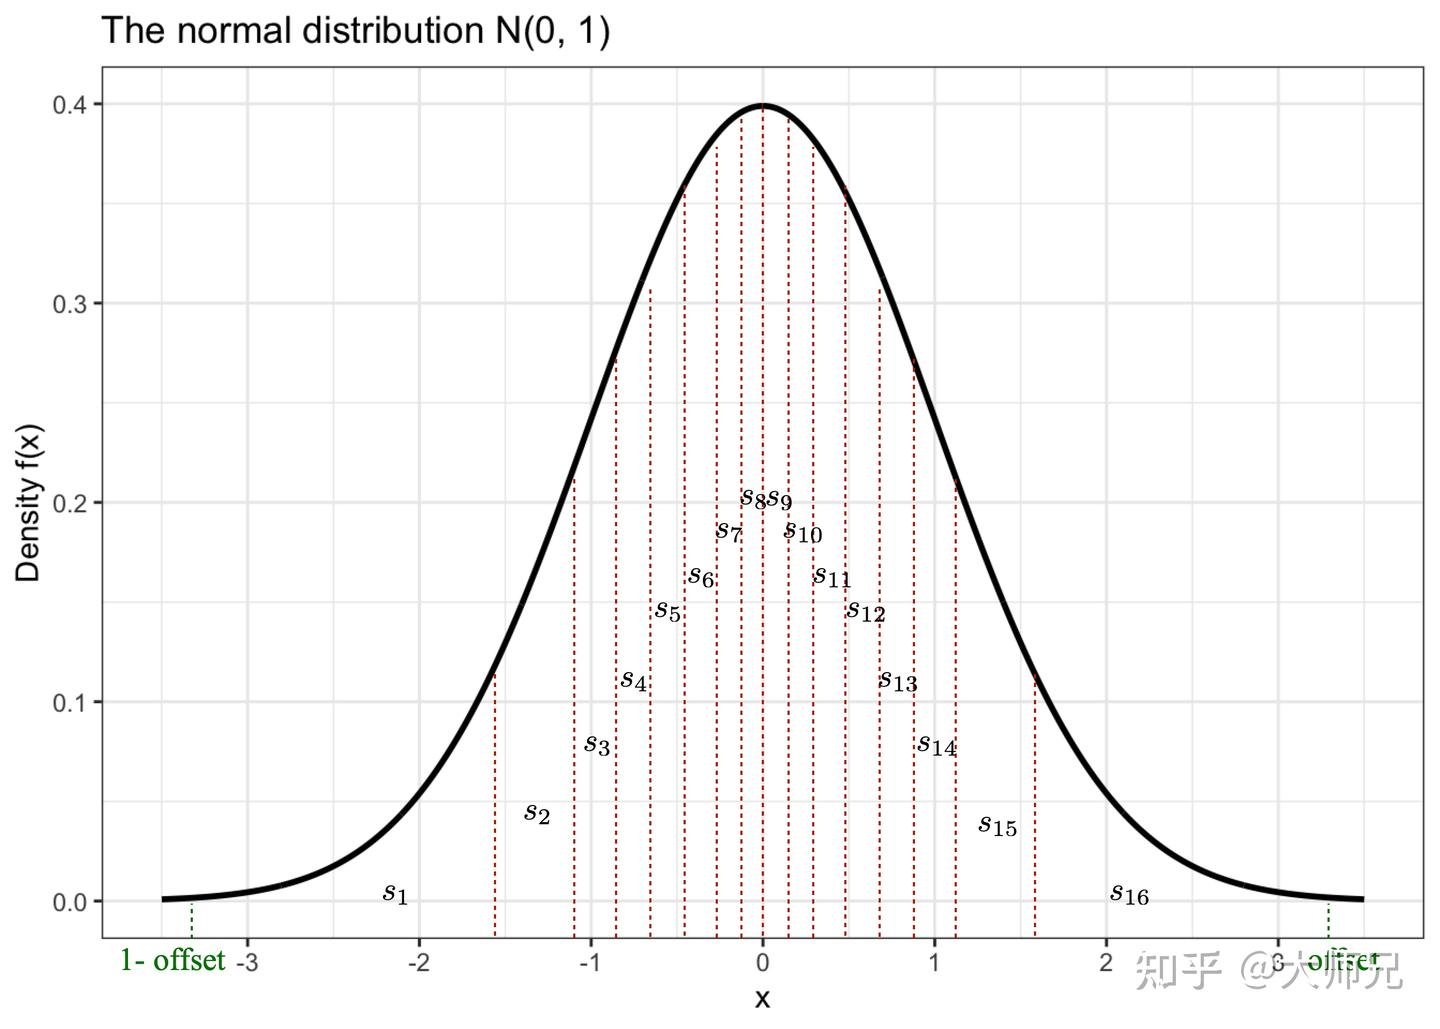

[QLoRA与大模型NF4量化](https://www.bilibili.com/video/BV1gALNzDEK8/)

**双重量化：**

量化常数（每个 block 的缩放因子，16 位浮点数）本身也占显存。双重量化就是对这些常数再做一次量化，进一步压缩空间。

**分页优化器：**

跟操作系统的分页内存类似——当显存不够时，把优化器状态暂时换到 CPU 内存，用时再换回来，避免 OOM。

### LoRA+：优化学习率

研究者发现，在训练过程中 A 和 B 的梯度规模差异很大，使用相同学习率会导致次优收敛。具体来说，当模型宽度 d 和 k 很大时，B 需要更大的学习率才能有效学习。

LoRA+ 是在 LoRA 基础上的一个简单但有效的改进，核心思想是： 为 LoRA 的两个低秩矩阵 A 和 B 设置不同的学习率 。

调整学习率：
$$\eta_B = \eta,   \eta_A = \frac{\eta}{\lambda}$$


**为什么 B 和 A 都乘到了输入 x 上，两者需要的梯度不同？**<br>

虽然 $\Delta W = B A$，但两者在梯度流中的位置是不对称的。

**计算梯度：**<br>
对 B 求梯度：
$$
\frac{\partial L}{\partial B_{ij}} = \frac{\partial L}{\partial (\Delta h)_i} \cdot z_j
$$
对 A 求梯度：
$$
\frac{\partial L}{\partial A_{ij}} = \sum_{m=1}^{d} B_{mi} \cdot \frac{\partial L}{\partial (\Delta h)_m} \cdot x_j
$$
A 的梯度有 d 维累加，梯度更大，需要更小的学习率，防止更新太快。

**换种方法理解，维度先降后升**<br>
```
x → [A] → z=Ax → [B] → Δh=Bz=BAx
    r×k          d×r
```
- A 离输入近，先和 $x$ 相乘：$z = Ax$（将 $k$ 维压缩到 $r$ 维）
    - 前向：$k$ 个输入汇聚到每一个 $z_i$
    - 反向：$d$ 个输出维度的梯度通过 $B$ 汇聚到每一个 $A_{ij}$
- B 离输出近，再和 $z$ 相乘：$\Delta h = Bz$（将 $r$ 维恢复到 $d$ 维）

故 A 梯度更大，需要更小的学习率，防止更新太快。B 梯度更小，需要更大的学习率，防止更新太慢。

### LoRA-FA：冻结 A（Frozen A）

```
标准 LoRA：同时训练 A 和 B
  ┌───┐
  │ B │ ← 训练
  ├───┤
  │ A │ ← 训练
  └───┘

LoRA-FA：冻结 A，只训练 B
  ┌───┐
  │ B │ ← 训练
  ├───┤
  │ A │ ← 冻结（随机初始化后固定不动）
  └───┘
```

**动机：**

A 用高斯随机初始化，在高维空间（k = 4096, r = 16）中，随机向量的内积期望为 0，方差为 O(1/ k)，所以 A 的行是近似正交的（以极高概率）。<br>
训练中（标准 LoRA）：如果 A 也被训练，它的行会在优化过程中漂移，正交性不再保证。<br>

随机初始化的 A 已经给出 r 个近似正交的输入侧方向。<br>
→ A 用 r 个方向 尽可能大地 覆盖了输入空间 $R^k$ 中的一个 r 维子空间。<br>
→ 这些方向足以覆盖微调所需的子空间。<br>
→ 冻结 A，只让 B 学习如何组合这些方向 → 参数量减半，效果不减。  


### DyLoRA：动态训练维度

DyLoRA 解决的是 LoRA 中一个实际问题：r 选多大合适？ 不同任务、不同资源预算可能需要不同的 r ，标准 LoRA 需要为每个 r 单独训练一份。

训练时不固定 $r$，而是每一个 $batch$ 随机采样一个 $r_b \in [r_{\min}, r_{\max}]$，只用 $\mathbf{A}$ 的前 $r_b$ 行、$\mathbf{B}$ 的前 $r_b$ 列做前向和反向：


```
步1: 采样 b=4 → 用 A[:4, :] 和 B[:, :4]
步2: 采样 b=16 → 用 A[:16, :] 和 B[:, :16]
步3: 采样 b=8 → 用 A[:8, :] 和 B[:, :8]
...
```

推理时可以选任意 $b \in [r_{\min}, r_{\max}]$，不需要重新训练。

**好处：**

训练时，$A$ 和 $B$ 的 $i$ 行/列比后面的更频繁被激活（小 $b$ 时只用到前面部分，大 $b$ 时才用到后面部分），自然形成了 "嵌套重要性"。

这使得最重要的更新信息集中在前几行/列，后面的行/列只负责补充细节。因此用较小的 $b$ 截断时，保留的是最重要的那部分。

**训练时随机采样不同的秩 b ，让模型学会"前几维重要、后几维补充"的嵌套结构，推理时按需截取，一次训练适配多种资源。**

### DP-DyLoRA：联邦学习FL+差分隐私DP

看不懂

### AdaLoRA：动态分配秩（Rank）

一个 Transformer 有几十到上百层，每层的重要性差别很大：
- 有些层的权重对下游任务非常敏感，需要更多可调参数
- 另外一些层的基座模型参数就够用了，不需要太多微调

所以需要动态分配秩，重要层 r 大，其他层 r 小。

**分配方法：**<br>

重要性 = 奇异值 × 梯度大小<br>
所有的重要性排序，取前面的作为重要层，加大 r 分配。

### Delta-LoRA：同时更新$W_0$

W₀ 的更新：
$$-\eta \cdot \Delta(BA)$$

### DoRA：方向和大小解耦

全量微调主要改变权重的方向，几乎不改大小；而标准 LoRA 把方向和大小混在一起更新，不够精细。

方向用 LoRA 更新，大小单独用一个可学习的标量 $m$ 更新：
$$w' = m \cdot \frac{W_0 + BA}{\|W_0 + BA\|}$$
- $\frac{W_0 + BA}{\|W_0 + BA\|}$为单位向量，只改变方向，不改变大小
- $m$ 是一个可学习的标量，用于调整大小


## Reference

[1] [SFT + LoRA 基础训练](https://haozhe-xing.github.io/agent_learning/zh/chapter_agentic_rl/02_sft_lora.html) <br>
[2] [Exploring different LoRA variants for efficient LLM Fine-Tuning](https://gautam75.medium.com/exploring-different-lora-variants-for-efficient-llm-fine-tuning-4ca41179e658) <br>
[3] [QLoRA原理分析](https://www.cnblogs.com/tgltt/p/18518597.html) <br>
[4] [QLoRA（Quantized LoRA）详解](https://zhuanlan.zhihu.com/p/666234324) <br>
[5] [QLoRA与大模型NF4量化](https://www.bilibili.com/video/BV1gALNzDEK8/) <br>
